# Diabetes Health Indicators - ML Project
## A complete Machine Learning pipeline for Binary Classification, Multiclass Classification, and Regression

## Step 1: Importing the Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Loading & Inspecting the Data

In [4]:
df = pd.read_csv("../data/raw/diabetes_dataset.csv")

In [6]:
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [18]:
# Data Loaded Successfully

print(f'Shape of Data : \n Rows :  {df.shape[0]} \n Columns : {df.shape[1]}')

Shape of Data : 
 Rows :  100000 
 Columns : 31


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [21]:
df.isnull().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


In [24]:
df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


In [27]:
df.duplicated().sum()

np.int64(0)

In [33]:
# Inspect target columns for each ML task
print("=== Binary Classification Target ===")
print(df['diagnosed_diabetes'].value_counts())

print("\n=== Multiclass Classification Target ===")
print(df['diabetes_stage'].value_counts())

print("\n=== Regression Target ===") 
print(df['diabetes_risk_score'].describe())

=== Binary Classification Target ===
diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64

=== Multiclass Classification Target ===
diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Gestational       278
Type 1            122
Name: count, dtype: int64

=== Regression Target ===
count    100000.000000
mean         30.222362
std           9.061505
min           2.700000
25%          23.800000
50%          29.000000
75%          35.600000
max          67.200000
Name: diabetes_risk_score, dtype: float64


## Step 3: Data Preprocessing
In this step we handle missing values, encode categorical variables, and normalize numerical features.

In [37]:
df.isnull().sum().sum()

np.int64(0)

In [51]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols  = df.select_dtypes(include=['int', 'float']).columns.tolist()

In [53]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()

for cols in categorical_cols : 
    df_encoded[cols] = le.fit_transform(df_encoded[cols])

In [56]:
df_encoded.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,1,0,1,2,0,2,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,4,1
1,48,0,4,1,3,0,1,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,1,0
2,60,1,2,1,3,3,2,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,4,1
3,74,0,1,1,1,1,2,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,4,1
4,46,1,4,0,3,1,2,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,4,1


In [59]:
# Define target columns
target_binary = 'diagnosed_diabetes'
target_multiclass = 'diabetes_stage'
target_regression = 'diabetes_risk_score'

feature_cols = [col for col in df_encoded.columns if col not in [target_binary, target_multiclass, target_regression]]

X = df_encoded[feature_cols]

# Targets
y_binary = df_encoded[target_binary]
y_multiclass = df_encoded[target_multiclass]
y_regression = df_encoded[target_regression]

print("✅ Features and targets separated!")
print(f"Features shape: {X.shape}")
print(f"Binary target shape: {y_binary.shape}")
print(f"Multiclass target shape: {y_multiclass.shape}")
print(f"Regression target shape: {y_regression.shape}")

✅ Features and targets separated!
Features shape: (100000, 28)
Binary target shape: (100000,)
Multiclass target shape: (100000,)
Regression target shape: (100000,)


In [60]:
from sklearn.preprocessing import StandardScaler

# Apply StandardScaler to normalize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print("✅ Features standardized successfully!")
X_scaled.head()

✅ Features standardized successfully!


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c
0,0.504956,0.895204,-1.700046,-0.000070,-0.448732,-0.681646,0.752904,-1.413253,1.138363,-0.165523,...,0.337328,-0.195041,1.656269,-1.270320,1.707081,0.542680,1.830223,2.455606,-0.545261,2.038566
1,-0.135884,-0.961951,0.984304,-0.000070,0.447835,-0.681646,-0.494390,-0.707921,0.285376,0.395977,...,0.093551,-0.314489,-2.185938,0.093229,-1.587310,-2.108775,-1.332578,-0.324388,-1.425352,-1.094431
2,0.633124,0.895204,-0.357871,-0.000070,0.447835,2.247772,0.752904,-0.707921,-0.733470,0.227527,...,-0.272115,0.521641,0.844095,1.164589,-0.119809,-1.970438,0.506260,1.130260,-0.805655,1.215387
3,1.530299,-0.961951,-1.028958,-0.000070,-1.345299,0.294826,0.752904,-1.413253,-0.828246,-1.456972,...,2.165658,-0.195041,-0.467878,-0.393753,-0.718789,0.427400,2.050884,3.005140,-0.763265,3.082899
4,-0.264052,0.895204,0.984304,-0.999945,0.447835,0.294826,0.752904,-0.707921,-0.117424,0.676727,...,-1.003447,-0.314489,0.750383,-0.198960,0.658865,0.888522,1.903777,0.774679,0.742578,0.834512


In [61]:
# Save processed data to data/processed/
df_encoded.to_csv("../data/processed/diabetes_processed.csv", index=False)

print("✅ Processed dataset saved to data/processed/diabetes_processed.csv")

✅ Processed dataset saved to data/processed/diabetes_processed.csv


## Step 4: Exploratory Data Analysis (EDA)
In this step we visualize the data to understand distributions, correlations, and patterns between features and target variables.

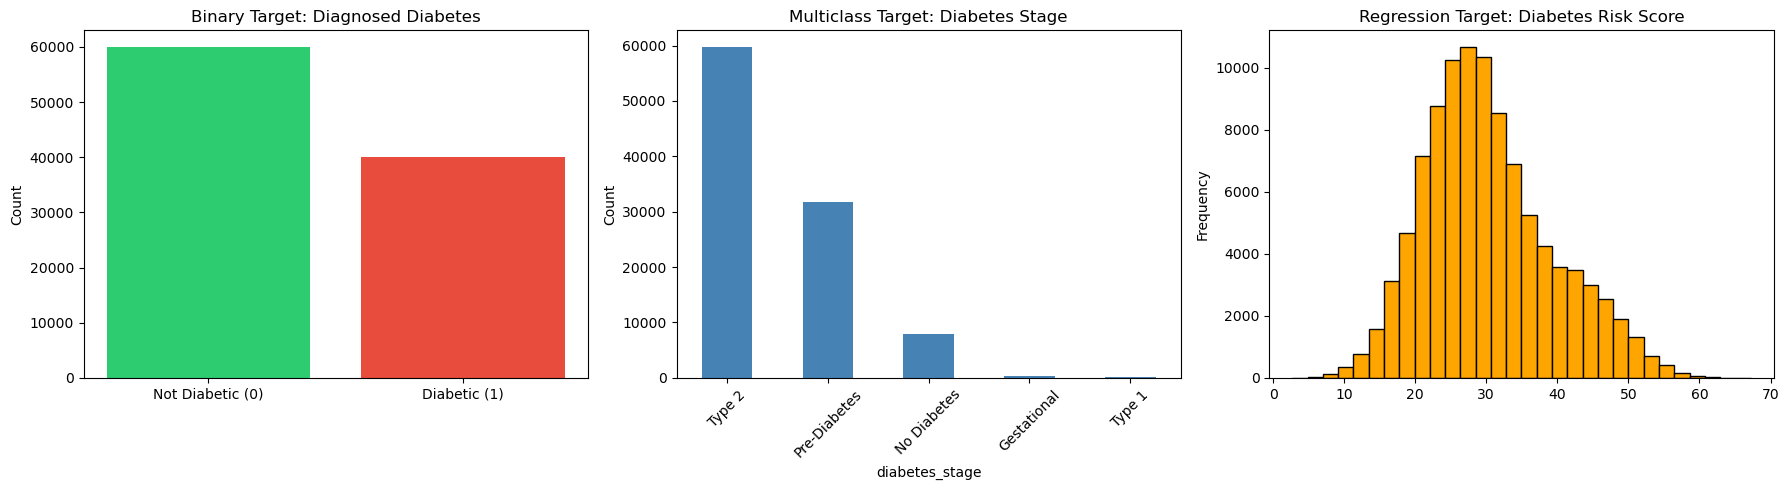

✅ Target distributions plotted!


In [62]:
# Distribution of Binary Target
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Binary Classification Target
axes[0].bar(['Not Diabetic (0)', 'Diabetic (1)'], 
            df['diagnosed_diabetes'].value_counts().values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Binary Target: Diagnosed Diabetes')
axes[0].set_ylabel('Count')

# Multiclass Target
df['diabetes_stage'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Multiclass Target: Diabetes Stage')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# Regression Target
axes[2].hist(df['diabetes_risk_score'], bins=30, color='orange', edgecolor='black')
axes[2].set_title('Regression Target: Diabetes Risk Score')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../reports/target_distributions.png')
plt.show()
print("✅ Target distributions plotted!")

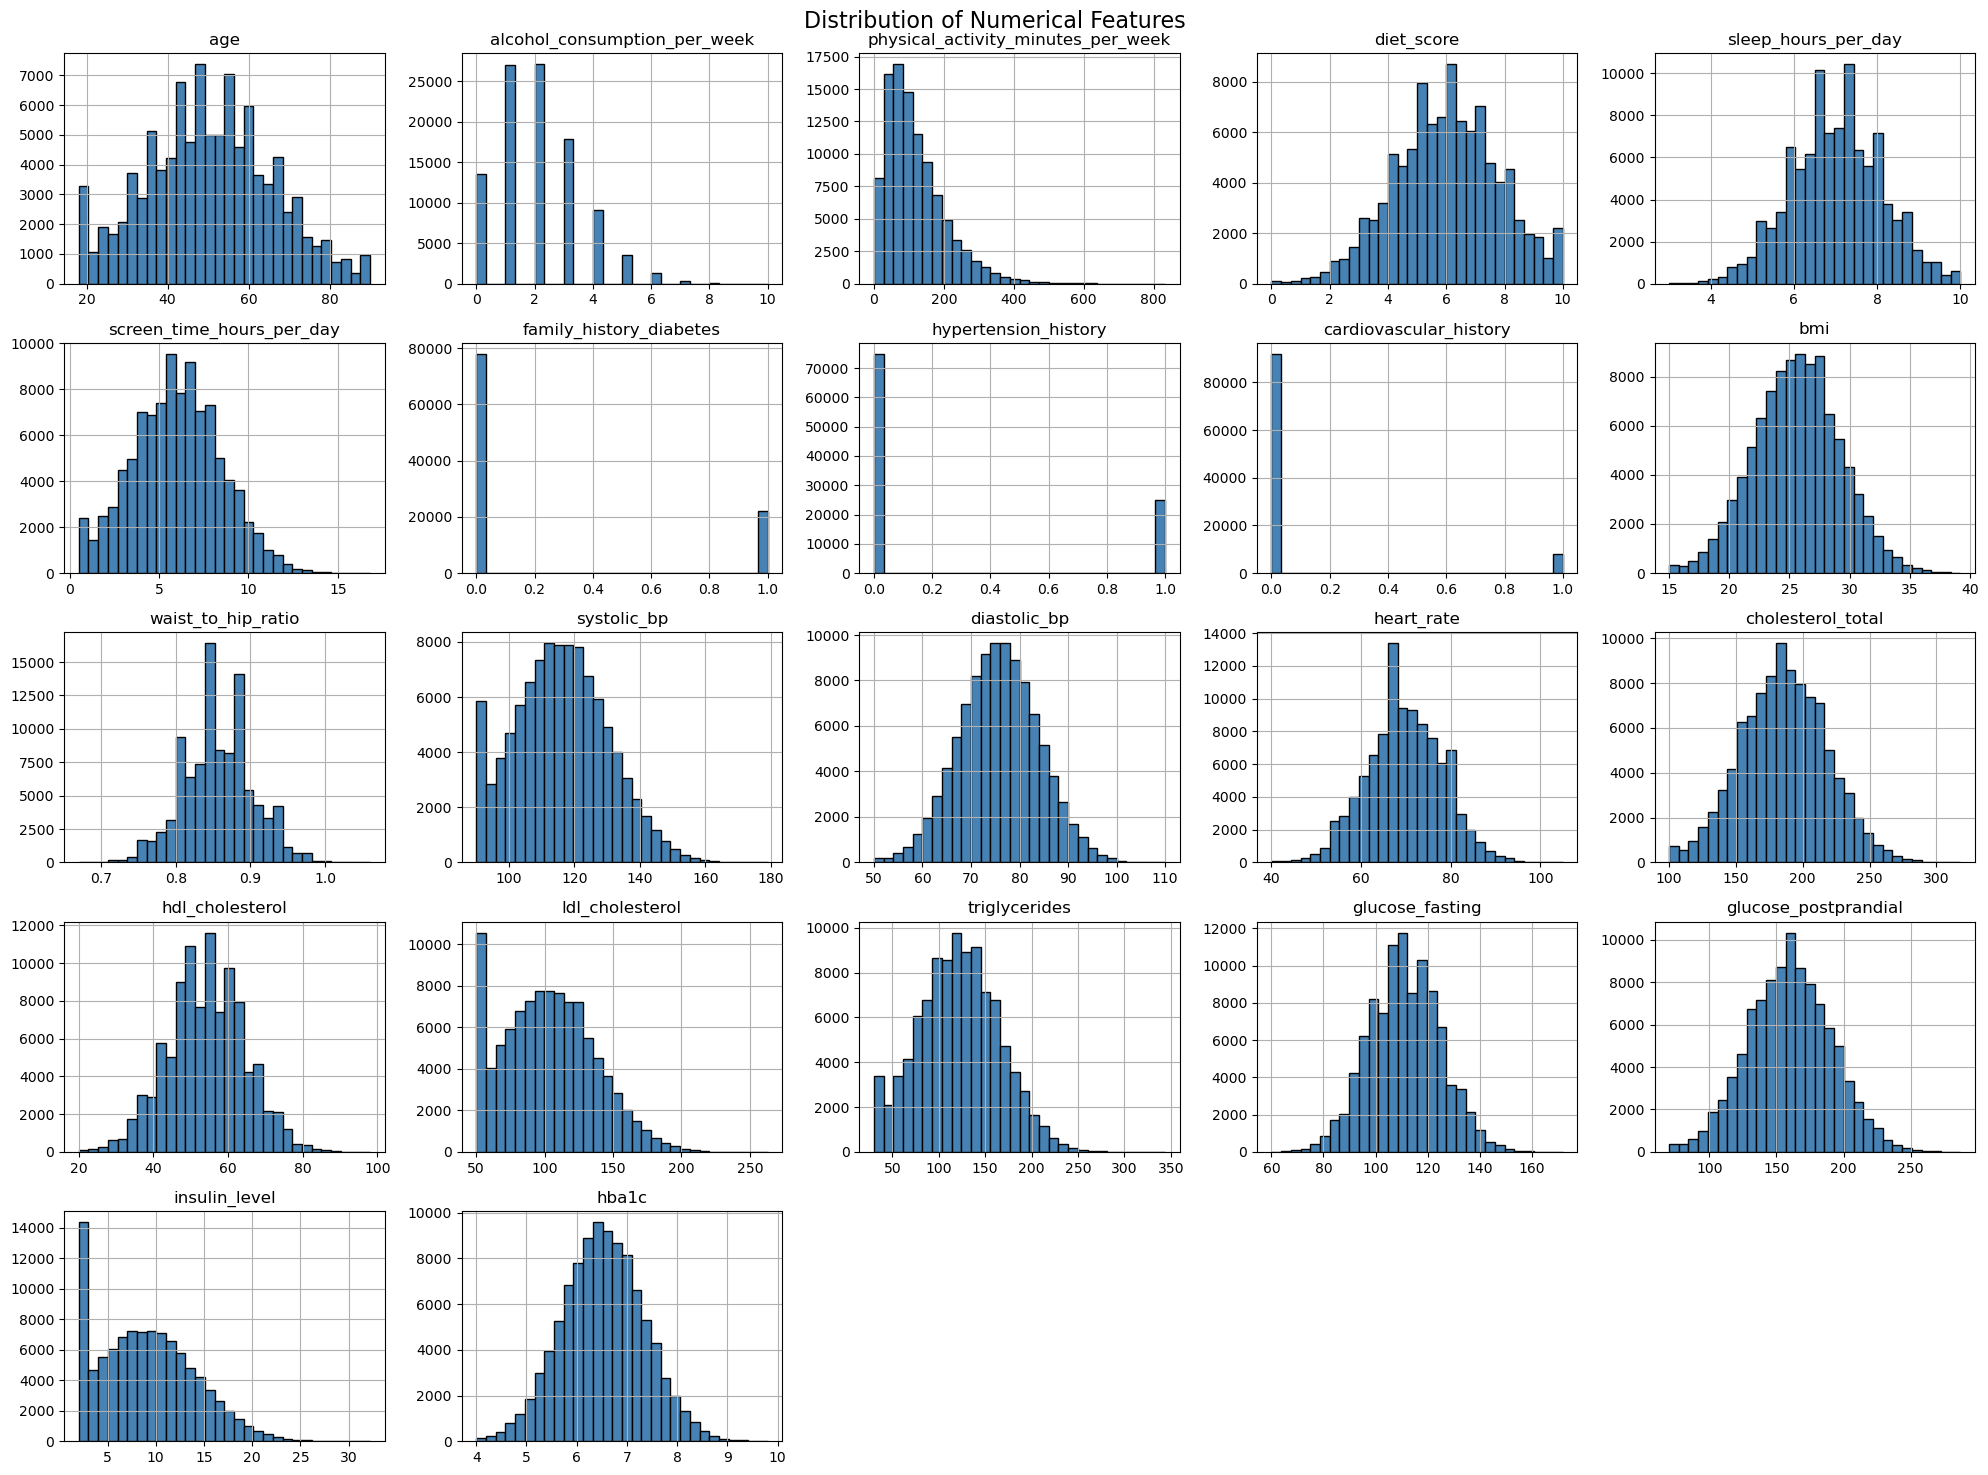

✅ Histograms plotted!


In [63]:
# Histograms of all numerical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in 
                  ['diagnosed_diabetes', 'diabetes_risk_score']]

df[numerical_cols].hist(figsize=(20, 15), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/feature_histograms.png')
plt.show()
print("✅ Histograms plotted!")

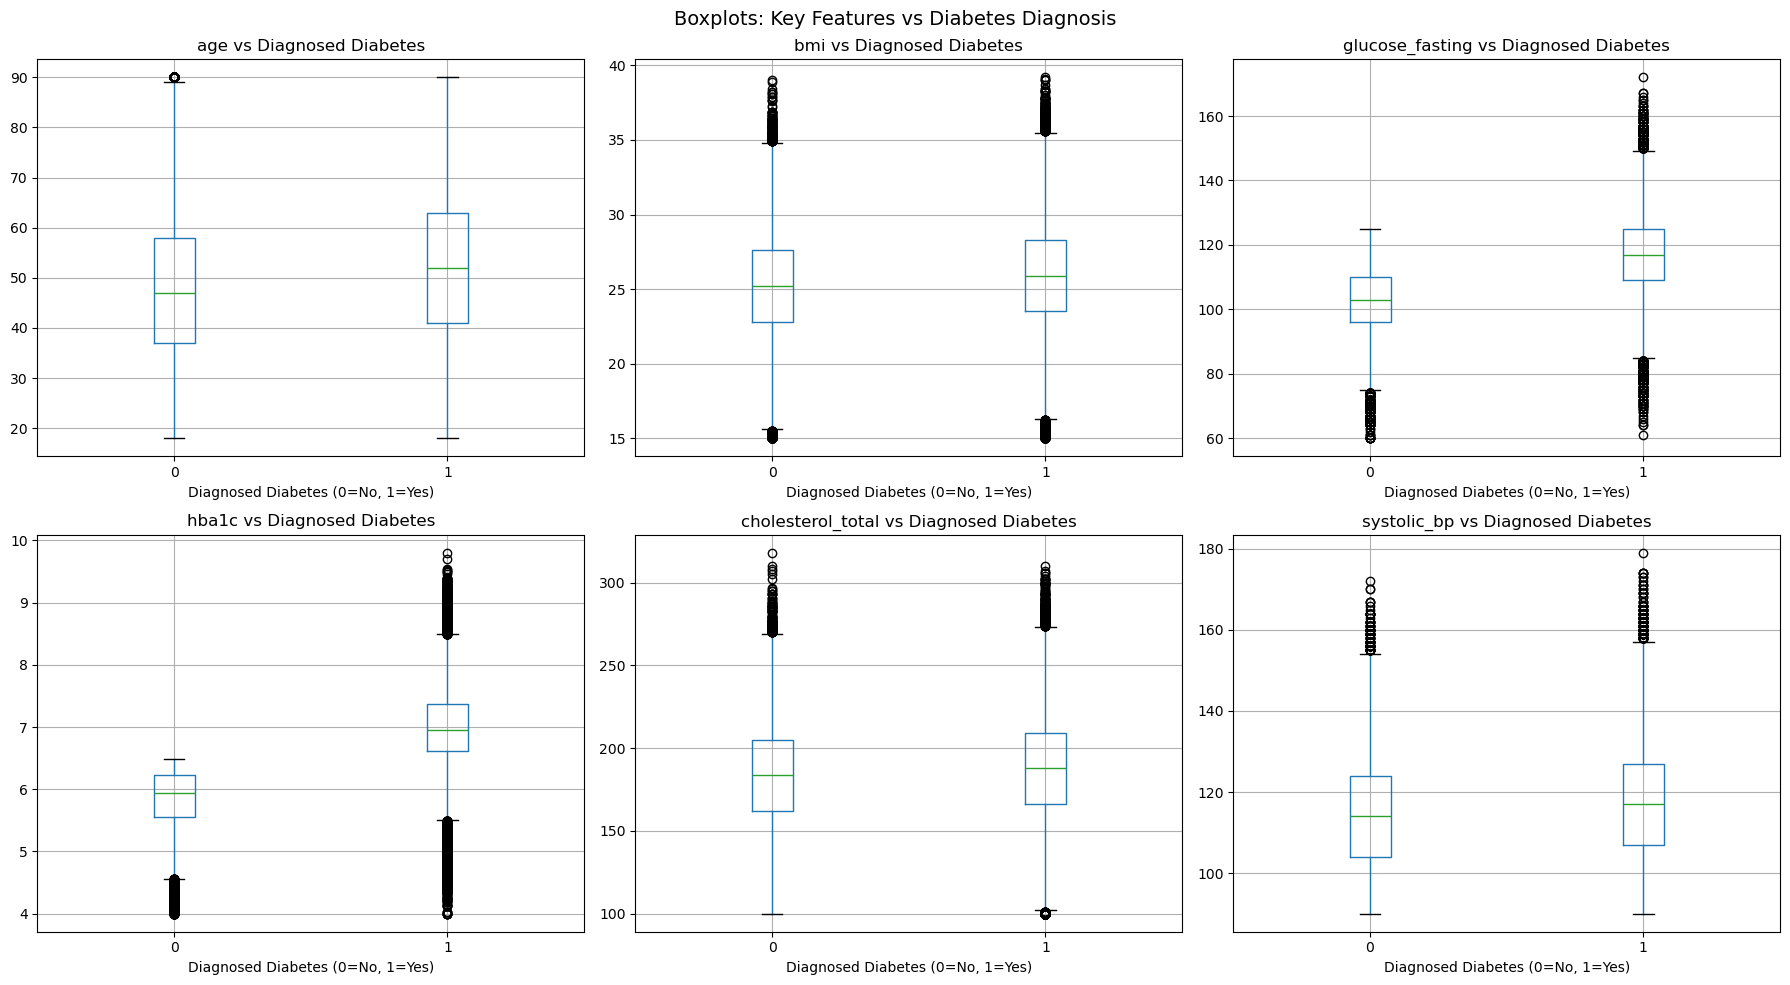

✅ Boxplots plotted!


In [64]:
# Boxplots of key clinical features vs diagnosed_diabetes
key_features = ['age', 'bmi', 'glucose_fasting', 'hba1c', 
                'cholesterol_total', 'systolic_bp']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    df.boxplot(column=col, by='diagnosed_diabetes', ax=axes[i])
    axes[i].set_title(f'{col} vs Diagnosed Diabetes')
    axes[i].set_xlabel('Diagnosed Diabetes (0=No, 1=Yes)')

plt.suptitle('Boxplots: Key Features vs Diabetes Diagnosis', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/boxplots.png')
plt.show()
print("✅ Boxplots plotted!")

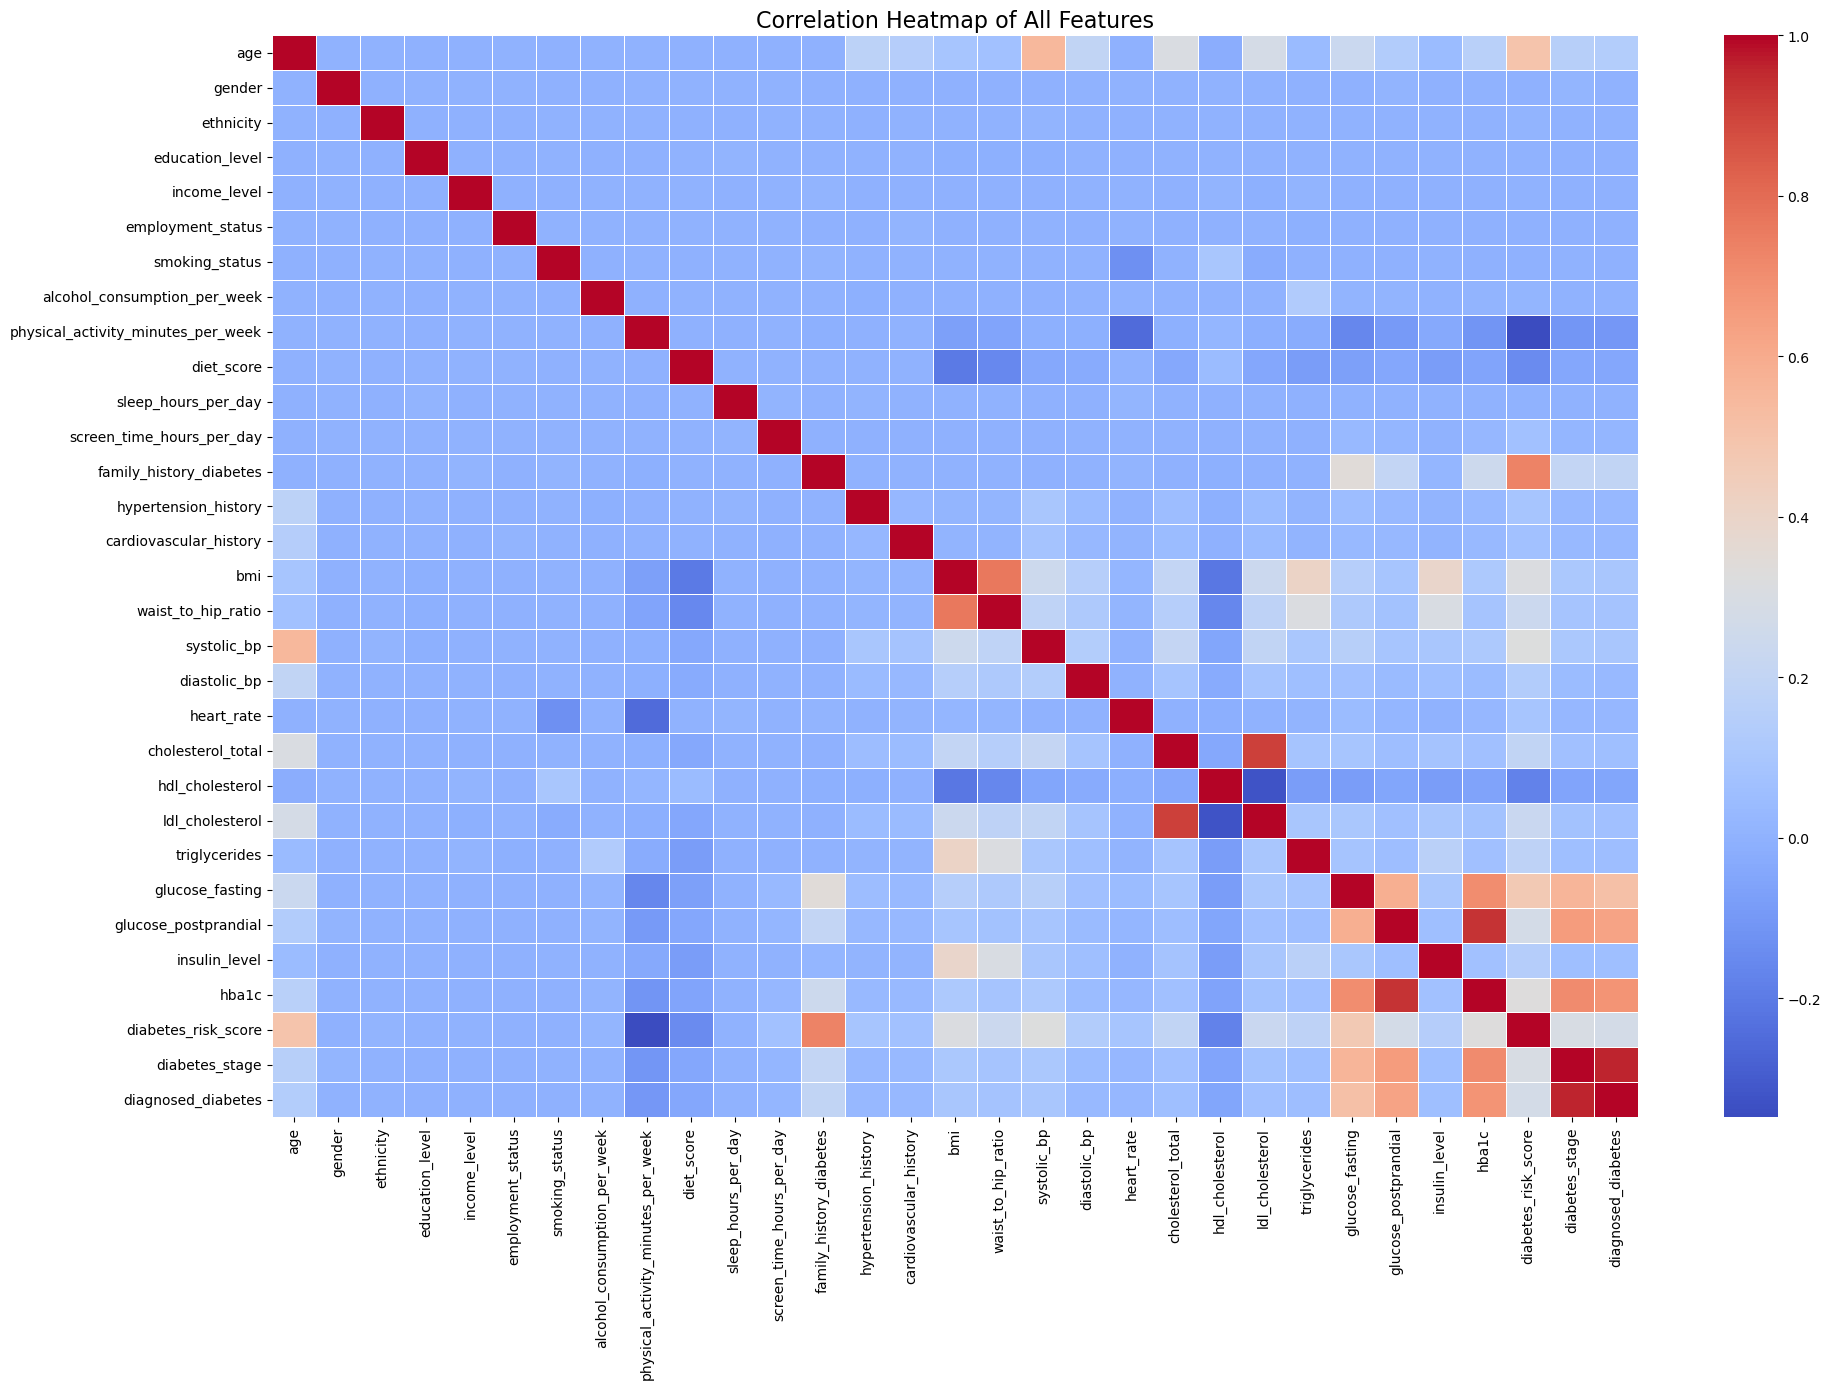

✅ Correlation heatmap plotted!


In [65]:
# Correlation Heatmap
plt.figure(figsize=(20, 14))
corr_matrix = df_encoded.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', 
            linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap of All Features', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png')
plt.show()
print("✅ Correlation heatmap plotted!")

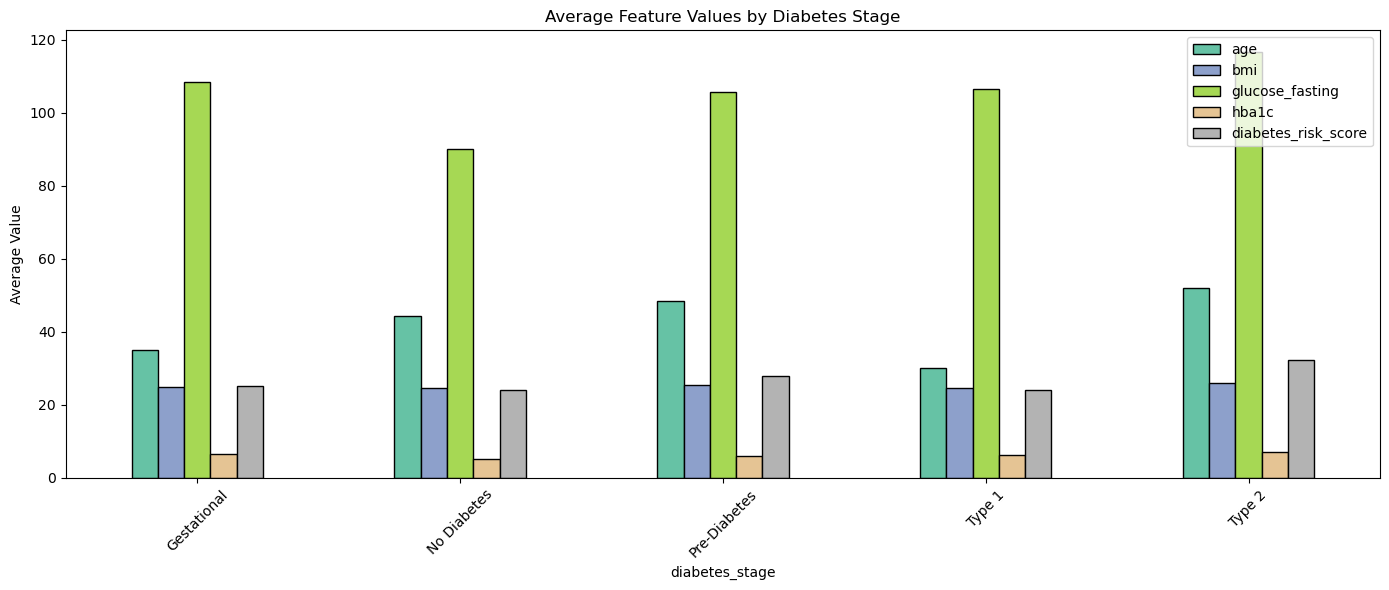

✅ Group-wise comparison plotted!


In [66]:
# Average values of key features grouped by diabetes stage
group_cols = ['age', 'bmi', 'glucose_fasting', 'hba1c', 'diabetes_risk_score']
grouped = df.groupby('diabetes_stage')[group_cols].mean()

grouped.plot(kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='black')
plt.title('Average Feature Values by Diabetes Stage')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/groupwise_comparison.png')
plt.show()
print("✅ Group-wise comparison plotted!")

## Step 5: Data Splitting
We split the dataset into 80% training and 20% testing sets.
Stratified splitting is used for classification tasks to maintain class balance.

In [67]:
from sklearn.model_selection import train_test_split

# Binary Classification Split (Stratified)
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_scaled, y_binary, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_binary
)

print("✅ Binary Classification Split:")
print(f"   Training set: {X_train_bin.shape}")
print(f"   Testing set:  {X_test_bin.shape}")

✅ Binary Classification Split:
   Training set: (80000, 28)
   Testing set:  (20000, 28)


In [68]:
# Multiclass Classification Split (Stratified)
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_scaled, y_multiclass, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_multiclass
)

print("✅ Multiclass Classification Split:")
print(f"   Training set: {X_train_multi.shape}")
print(f"   Testing set:  {X_test_multi.shape}")

✅ Multiclass Classification Split:
   Training set: (80000, 28)
   Testing set:  (20000, 28)


In [69]:
# Regression Split (No stratification needed)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_scaled, y_regression, 
    test_size=0.2, 
    random_state=42
)

print("✅ Regression Split:")
print(f"   Training set: {X_train_reg.shape}")
print(f"   Testing set:  {X_test_reg.shape}")

✅ Regression Split:
   Training set: (80000, 28)
   Testing set:  (20000, 28)


## Step 6: Baseline Model Training & Evaluation

### 6A: Binary Classification (Target: diagnosed_diabetes)
Models: Logistic Regression, Decision Tree, KNN
Metrics: Accuracy, Precision, Recall, F1-score, ROC-AUC

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay)

print("✅ All libraries imported!")

✅ All libraries imported!


In [71]:
# Define binary models
binary_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

binary_results = {}

for name, model in binary_models.items():
    # Train
    model.fit(X_train_bin, y_train_bin)
    # Predict
    y_pred = model.predict(X_test_bin)
    y_prob = model.predict_proba(X_test_bin)[:, 1]
    
    # Metrics
    binary_results[name] = {
        'Accuracy':  accuracy_score(y_test_bin, y_pred),
        'Precision': precision_score(y_test_bin, y_pred),
        'Recall':    recall_score(y_test_bin, y_pred),
        'F1-Score':  f1_score(y_test_bin, y_pred),
        'ROC-AUC':   roc_auc_score(y_test_bin, y_prob)
    }
    print(f"\n✅ {name} trained!")
    print(classification_report(y_test_bin, y_pred))

# Summary table
binary_results_df = pd.DataFrame(binary_results).T
print("\n=== Binary Classification Results Summary ===")
print(binary_results_df.round(4))


✅ Logistic Regression trained!
              precision    recall  f1-score   support

           0       0.84      0.81      0.82      8000
           1       0.87      0.90      0.88     12000

    accuracy                           0.86     20000
   macro avg       0.86      0.85      0.85     20000
weighted avg       0.86      0.86      0.86     20000


✅ Decision Tree trained!
              precision    recall  f1-score   support

           0       0.84      0.81      0.82      8000
           1       0.88      0.89      0.89     12000

    accuracy                           0.86     20000
   macro avg       0.86      0.85      0.85     20000
weighted avg       0.86      0.86      0.86     20000


✅ KNN trained!
              precision    recall  f1-score   support

           0       0.75      0.77      0.76      8000
           1       0.84      0.83      0.84     12000

    accuracy                           0.81     20000
   macro avg       0.80      0.80      0.80     20000


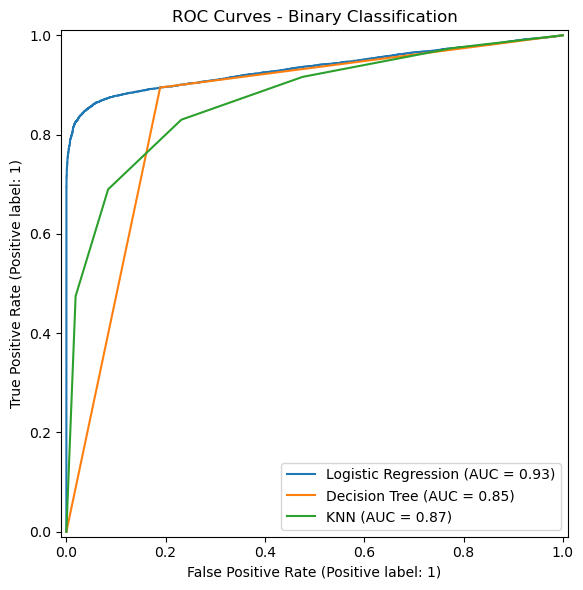

✅ ROC Curves plotted!


In [72]:
# Plot ROC Curves for all binary models
fig, ax = plt.subplots(figsize=(10, 6))

for name, model in binary_models.items():
    RocCurveDisplay.from_estimator(model, X_test_bin, y_test_bin, ax=ax, name=name)

ax.set_title('ROC Curves - Binary Classification')
plt.tight_layout()
plt.savefig('../reports/roc_curves_binary.png')
plt.show()
print("✅ ROC Curves plotted!")

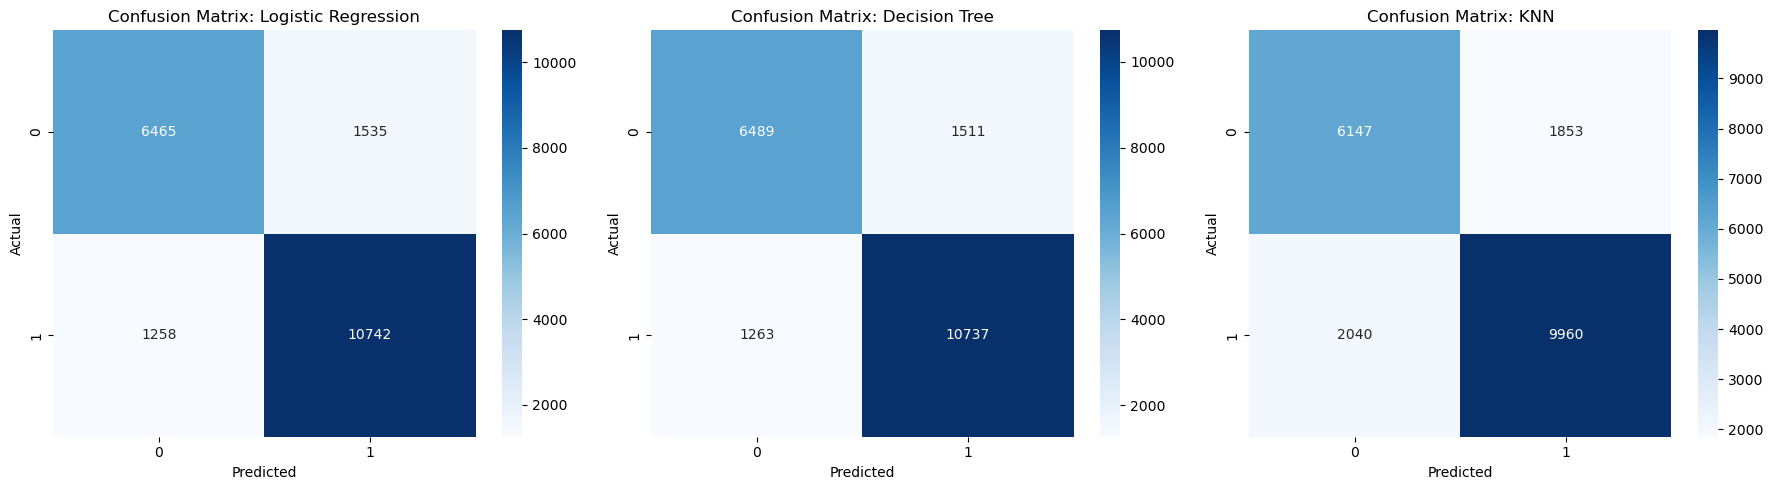

✅ Confusion Matrices plotted!


In [73]:
# Confusion Matrices for Binary Models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(binary_models.items()):
    y_pred = model.predict(X_test_bin)
    cm = confusion_matrix(y_test_bin, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../reports/confusion_matrices_binary.png')
plt.show()
print("✅ Confusion Matrices plotted!")

### 6B: Multiclass Classification (Target: diabetes_stage)
Models: Decision Tree, Logistic Regression, KNN
Metrics: Accuracy, Confusion Matrix, Macro-F1

In [75]:
from sklearn.metrics import ConfusionMatrixDisplay

# Define multiclass models
multiclass_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

multiclass_results = {}

for name, model in multiclass_models.items():
    # Train
    model.fit(X_train_multi, y_train_multi)
    # Predict
    y_pred = model.predict(X_test_multi)
    
    # Metrics
    multiclass_results[name] = {
        'Accuracy': accuracy_score(y_test_multi, y_pred),
        'Macro-F1': f1_score(y_test_multi, y_pred, average='macro', zero_division=0)
    }
    print(f"\n✅ {name} trained!")
    print(classification_report(y_test_multi, y_pred, zero_division=0))

# Summary table
multiclass_results_df = pd.DataFrame(multiclass_results).T
print("\n=== Multiclass Classification Results Summary ===")
print(multiclass_results_df.round(4))


✅ Logistic Regression trained!
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        56
           1       0.77      0.67      0.72      1596
           2       0.74      0.72      0.73      6369
           3       0.00      0.00      0.00        24
           4       0.86      0.90      0.88     11955

    accuracy                           0.82     20000
   macro avg       0.48      0.46      0.47     20000
weighted avg       0.81      0.82      0.82     20000


✅ Decision Tree trained!
              precision    recall  f1-score   support

           0       0.03      0.04      0.03        56
           1       0.85      0.83      0.84      1596
           2       0.83      0.80      0.82      6369
           3       0.00      0.00      0.00        24
           4       0.87      0.89      0.88     11955

    accuracy                           0.85     20000
   macro avg       0.52      0.51      0.51     20000
weighted avg       

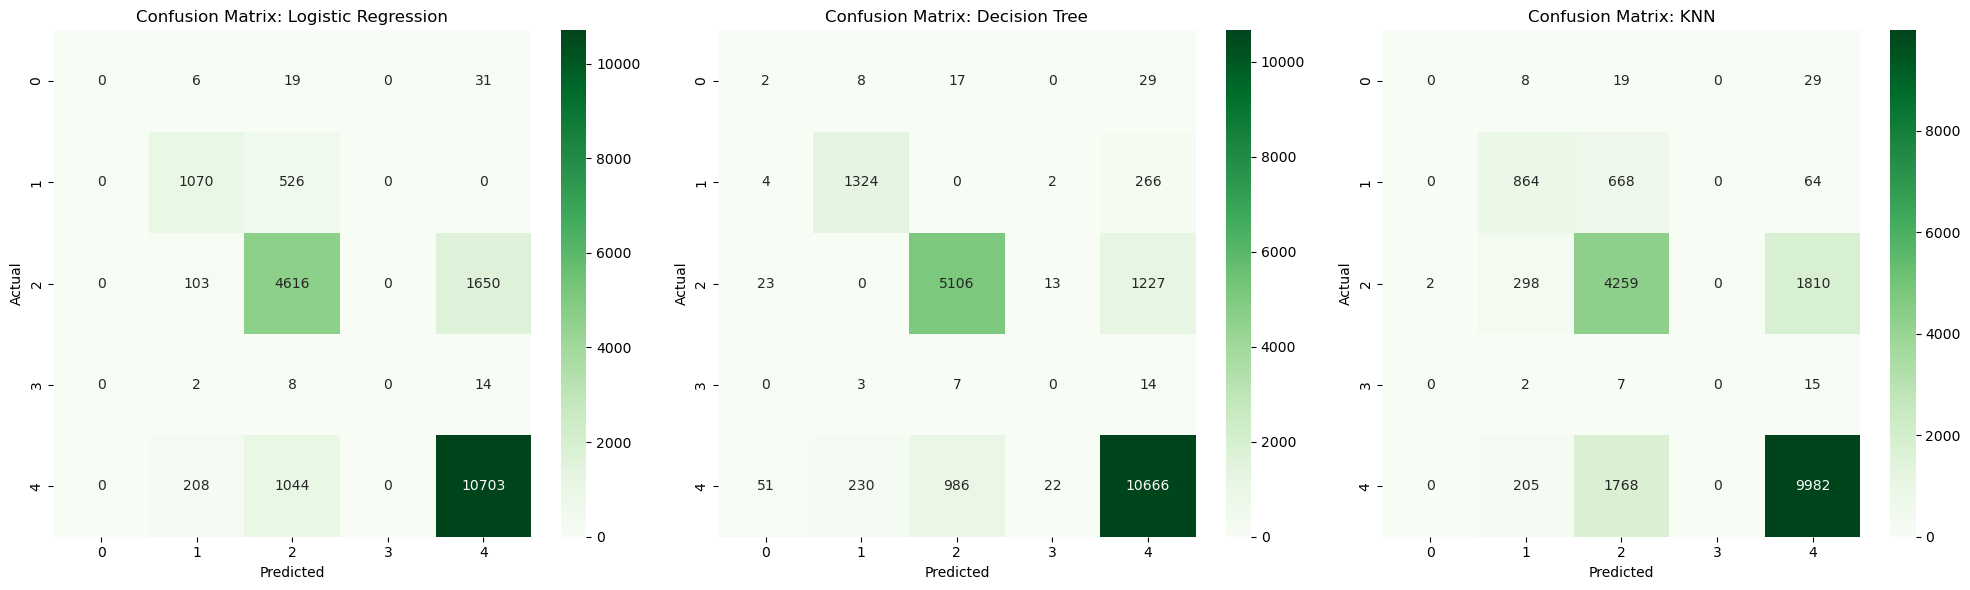

✅ Multiclass Confusion Matrices plotted!


In [76]:
# Confusion Matrices for Multiclass Models
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (name, model) in enumerate(multiclass_models.items()):
    y_pred = model.predict(X_test_multi)
    cm = confusion_matrix(y_test_multi, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../reports/confusion_matrices_multiclass.png')
plt.show()
print("✅ Multiclass Confusion Matrices plotted!")

### 6C: Regression (Target: diabetes_risk_score)
Models: Linear Regression, Decision Tree Regressor
Metrics: MAE, MSE, RMSE, R²

In [77]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define regression models
regression_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42)
}

regression_results = {}

for name, model in regression_models.items():
    # Train
    model.fit(X_train_reg, y_train_reg)
    # Predict
    y_pred = model.predict(X_test_reg)
    
    # Metrics
    mae = mean_absolute_error(y_test_reg, y_pred)
    mse = mean_squared_error(y_test_reg, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_reg, y_pred)
    
    regression_results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2
    }
    print(f"✅ {name} trained!")
    print(f"   MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}\n")

# Summary table
regression_results_df = pd.DataFrame(regression_results).T
print("\n=== Regression Results Summary ===")
print(regression_results_df.round(4))

✅ Linear Regression trained!
   MAE: 0.4390 | MSE: 0.5544 | RMSE: 0.7446 | R²: 0.9933

✅ Decision Tree Regressor trained!
   MAE: 1.2478 | MSE: 2.5459 | RMSE: 1.5956 | R²: 0.9692


=== Regression Results Summary ===
                            MAE     MSE    RMSE      R²
Linear Regression        0.4390  0.5544  0.7446  0.9933
Decision Tree Regressor  1.2478  2.5459  1.5956  0.9692


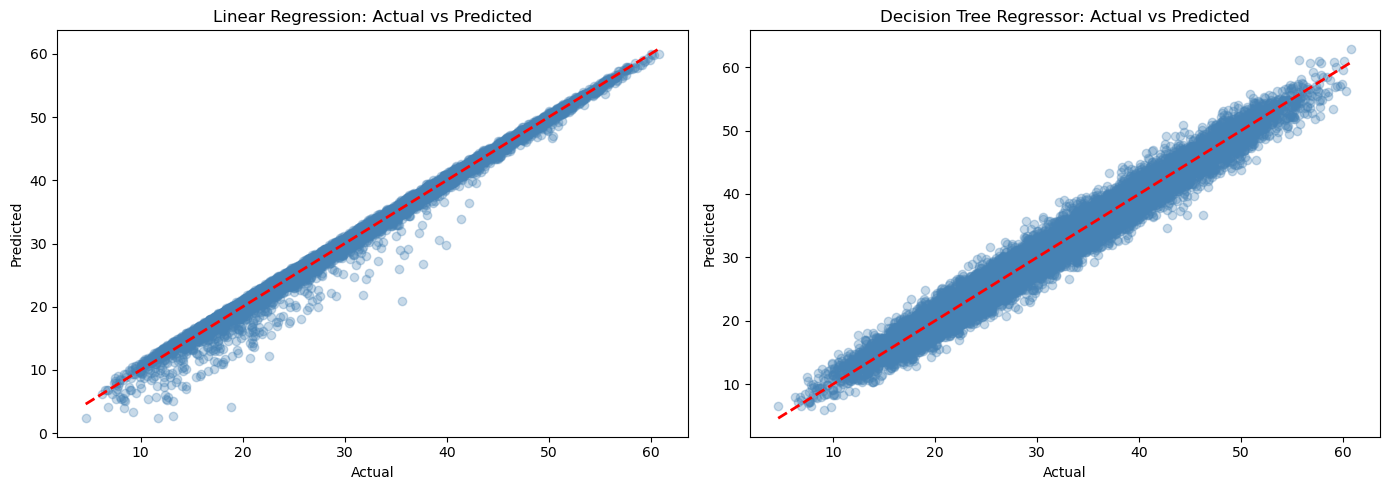

✅ Regression plots saved!


In [78]:
# Actual vs Predicted plots for regression models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, model) in enumerate(regression_models.items()):
    y_pred = model.predict(X_test_reg)
    axes[i].scatter(y_test_reg, y_pred, alpha=0.3, color='steelblue')
    axes[i].plot([y_test_reg.min(), y_test_reg.max()], 
                 [y_test_reg.min(), y_test_reg.max()], 
                 'r--', linewidth=2)
    axes[i].set_title(f'{name}: Actual vs Predicted')
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')

plt.tight_layout()
plt.savefig('../reports/regression_actual_vs_predicted.png')
plt.show()
print("✅ Regression plots saved!")

## Step 7: Hyperparameter Tuning
We apply Grid Search with Cross-Validation to tune the best performing models for each task.
Best parameters are recorded and final models are exported using joblib.

In [79]:
from sklearn.model_selection import GridSearchCV
import joblib

print("✅ Libraries imported!")

✅ Libraries imported!


### 7A: Tuning Binary Classification Models

In [80]:
# Tune Logistic Regression for Binary Classification
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [500, 1000]
}

grid_lr_bin = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_lr_bin.fit(X_train_bin, y_train_bin)

print(f"\n✅ Best Parameters (LR Binary): {grid_lr_bin.best_params_}")
print(f"Best CV F1 Score: {grid_lr_bin.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

✅ Best Parameters (LR Binary): {'C': 0.01, 'max_iter': 500, 'solver': 'liblinear'}
Best CV F1 Score: 0.8841


In [81]:
# Tune Decision Tree for Binary Classification
param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt_bin = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_dt_bin.fit(X_train_bin, y_train_bin)

print(f"\n✅ Best Parameters (DT Binary): {grid_dt_bin.best_params_}")
print(f"Best CV F1 Score: {grid_dt_bin.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Best Parameters (DT Binary): {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
Best CV F1 Score: 0.9299


In [82]:
# Evaluate tuned binary models
tuned_binary_models = {
    'Tuned Logistic Regression': grid_lr_bin.best_estimator_,
    'Tuned Decision Tree': grid_dt_bin.best_estimator_
}

tuned_binary_results = {}

for name, model in tuned_binary_models.items():
    y_pred = model.predict(X_test_bin)
    y_prob = model.predict_proba(X_test_bin)[:, 1]
    
    tuned_binary_results[name] = {
        'Accuracy':  accuracy_score(y_test_bin, y_pred),
        'Precision': precision_score(y_test_bin, y_pred),
        'Recall':    recall_score(y_test_bin, y_pred),
        'F1-Score':  f1_score(y_test_bin, y_pred),
        'ROC-AUC':   roc_auc_score(y_test_bin, y_prob)
    }
    print(f"\n✅ {name} evaluated!")
    print(classification_report(y_test_bin, y_pred))

tuned_binary_df = pd.DataFrame(tuned_binary_results).T
print("\n=== Tuned Binary Classification Results ===")
print(tuned_binary_df.round(4))


✅ Tuned Logistic Regression evaluated!
              precision    recall  f1-score   support

           0       0.84      0.81      0.82      8000
           1       0.87      0.89      0.88     12000

    accuracy                           0.86     20000
   macro avg       0.85      0.85      0.85     20000
weighted avg       0.86      0.86      0.86     20000


✅ Tuned Decision Tree evaluated!
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      8000
           1       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000


=== Tuned Binary Classification Results ===
                           Accuracy  Precision  Recall  F1-Score  ROC-AUC
Tuned Logistic Regression    0.8594     0.8742  0.8942    0.8841   0.9334
Tuned Decision Tree          0.9198     0.9999  0.8665    0.9284   0.9431


### 7B: Tuning Multiclass Classification Models

In [83]:
# Tune Decision Tree for Multiclass Classification
grid_dt_multi = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_dt_multi.fit(X_train_multi, y_train_multi)

print(f"\n✅ Best Parameters (DT Multiclass): {grid_dt_multi.best_params_}")
print(f"Best CV Macro-F1 Score: {grid_dt_multi.best_score_:.4f}")

# Evaluate
y_pred = grid_dt_multi.best_estimator_.predict(X_test_multi)
print(f"\nTuned DT Multiclass Accuracy: {accuracy_score(y_test_multi, y_pred):.4f}")
print(f"Tuned DT Macro-F1: {f1_score(y_test_multi, y_pred, average='macro', zero_division=0):.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Best Parameters (DT Multiclass): {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
Best CV Macro-F1 Score: 0.5501

Tuned DT Multiclass Accuracy: 0.9184
Tuned DT Macro-F1: 0.5506


### 7C: Tuning Regression Models

In [84]:
# Tune Decision Tree Regressor
param_grid_reg = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
}

grid_dt_reg = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_reg,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_dt_reg.fit(X_train_reg, y_train_reg)

print(f"\n✅ Best Parameters (DT Regression): {grid_dt_reg.best_params_}")
print(f"Best CV R² Score: {grid_dt_reg.best_score_:.4f}")

# Evaluate
y_pred = grid_dt_reg.best_estimator_.predict(X_test_reg)
print(f"\nTuned DT Regression MAE:  {mean_absolute_error(y_test_reg, y_pred):.4f}")
print(f"Tuned DT Regression RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred)):.4f}")
print(f"Tuned DT Regression R²:   {r2_score(y_test_reg, y_pred):.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Best Parameters (DT Regression): {'max_depth': None, 'min_samples_split': 10}
Best CV R² Score: 0.9699

Tuned DT Regression MAE:  1.1937
Tuned DT Regression RMSE: 1.5215
Tuned DT Regression R²:   0.9719


In [85]:
# Export best models to models/ directory
joblib.dump(grid_lr_bin.best_estimator_, '../models/binary_model.joblib')
joblib.dump(grid_dt_multi.best_estimator_, '../models/multiclass_model.joblib')
joblib.dump(grid_dt_reg.best_estimator_, '../models/regression_model.joblib')
joblib.dump(scaler, '../models/scaler.joblib')

print("✅ All models exported to models/ directory!")
print("   - binary_model.joblib")
print("   - multiclass_model.joblib")
print("   - regression_model.joblib")
print("   - scaler.joblib")

✅ All models exported to models/ directory!
   - binary_model.joblib
   - multiclass_model.joblib
   - regression_model.joblib
   - scaler.joblib
